In [54]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np 
from sympy import *

In [62]:
T= sp.symbols('T')

pi = sp.pi
n = sp.symbols('n' , positive = True , integer = True)
u = sp.symbols('u')


sp.integrate(sp.sin(n*T), (T, 0,pi))


-(-1)**n/n + 1/n

In [ ]:
# right so I need to discretise this now 
radius = 2 
D = 50



a = radius
# I need to find out how polar plots in matplotlib takes information and 
u = 1 

# I want a value for u(r,theta) for each of these points (with accuracy n) from my analytical solution 
def simulation(N):  # pick an n value for the Fourier series
    
    r = np.linspace(0, radius , D) # this gives me each 50 possible values r can take
    theta = np.linspace(-np.pi, np.pi , D) # this sets my discretisation for theta  from - pi to pi 
    U = np.zeros((len(theta), len(r))) # empty array for storage of values 
    n = np.arange(1,N+1)  # an array for n going between 1 and the desired n value 
    
    

    for i in range (len(n)):
        for j in range(len(r)):
            U[ :,j] += (  (r[j])**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta)  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )  
    return U
    # += needed to sum the fourier terms 

simulation(10)

array([[ 0.00000000e+00, -3.18350700e-18, -6.37498272e-18, ...,
        -1.25340480e-15, -1.53412679e-15, -1.89608854e-15],
       [ 0.00000000e+00, -3.32417591e-03, -6.65649057e-03, ...,
        -8.37041174e-01, -9.73880755e-01, -1.14224685e+00],
       [ 0.00000000e+00, -6.59359310e-03, -1.32022700e-02, ...,
        -8.91124376e-01, -9.34764678e-01, -9.70687742e-01],
       ...,
       [ 0.00000000e+00,  6.59359310e-03,  1.32022700e-02, ...,
         8.91124376e-01,  9.34764678e-01,  9.70687742e-01],
       [ 0.00000000e+00,  3.32417591e-03,  6.65649057e-03, ...,
         8.37041174e-01,  9.73880755e-01,  1.14224685e+00],
       [ 0.00000000e+00,  3.18350700e-18,  6.37498272e-18, ...,
         1.25340480e-15,  1.53412679e-15,  1.89608854e-15]],
      shape=(50, 50))

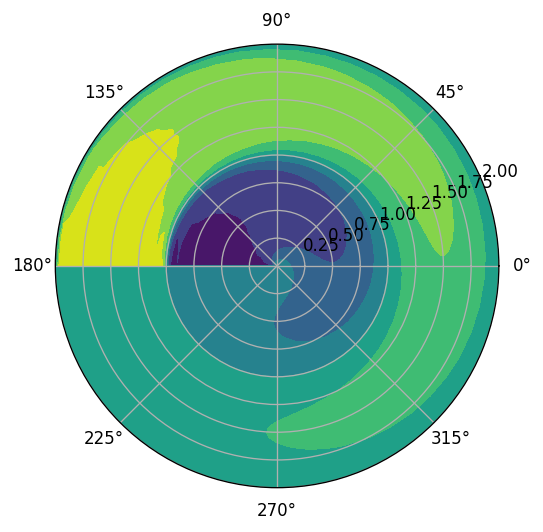

In [81]:
xs, ys = np.meshgrid(r, theta, sparse = True)

zs = simulation(10)
xs.shape

#h = plt.contourf(theta, r, zs)
#plt.colorbar()
#plt.show()
plt.subplots( dpi = 120, subplot_kw=dict(projection = 'polar') )   #fig, ax = 
plt.contourf(theta, r, zs)
plt.show()

#well this is very wrong the information is being presented to subplots in the the wrong way 
# i can try and infer from the plot what is actually going wrong 

In [ ]:
U
# ok so the main problem is that python does not understand circles or polar coordinates only indexing 
# I will have to create a square matrix of the size of the circle and get it to enter my values from U into it starting from the first theta and cycling that for each value of r
# starting with the center of the circle where r = 0 ~ this is going to be a big problem, and going round ever 
# the points will be very dense in the middle and then further away for the larger r values 

# using np.meshgrid and plt.subplot(subplot_kw={'projection' : 'polar'}) ~ need to understand how python is doing this polar coordinate system 

# what form do I want U to be in I almost want it as a function 

array([0., 0., 0., ..., 0., 0., 0.], shape=(2500,))